# CNN을 이용한 Multi-label classification 실습

데이터파일 압축해제

In [ ]:
import zipfile
zipfile.ZipFile('miml_dataset.zip').extractall()

Module import

In [5]:
from keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.layers import Dense, Activation, Flatten, Dropout, BatchNormalization
from keras.layers import Conv2D, MaxPooling2D
from keras import regularizers, optimizers
import pandas as pd
import numpy as np

데이터셋 구성 및 전처리

In [6]:
df=pd.read_csv('miml_labels_1.csv')
columns=["desert", "mountains", "sea", "sunset", "trees"]
datagen=ImageDataGenerator(rescale=1./255.)
test_datagen=ImageDataGenerator(rescale=1./255.)
train_generator=datagen.flow_from_dataframe(dataframe=df[:1800],
                                            directory="./images",
                                            x_col="Filenames",
                                            y_col=columns,
                                            batch_size=32,
                                            seed=42,
                                            shuffle=True,
                                            class_mode="raw",
                                            target_size=(100,100))

valid_generator=test_datagen.flow_from_dataframe(dataframe=df[1800:1900],
                                                 directory="./images",
                                                 x_col="Filenames",
                                                 y_col=columns,
                                                 batch_size=32,
                                                 seed=42,
                                                 shuffle=True,
                                                 class_mode="raw",
                                                 target_size=(100,100))

test_generator=test_datagen.flow_from_dataframe(dataframe=df[1900:],
                                                directory="./images",
                                                x_col="Filenames",
                                                batch_size=1,
                                                seed=42,
                                                shuffle=False,
                                                class_mode=None,
                                                target_size=(100,100))

Found 1800 validated image filenames.
Found 100 validated image filenames.
Found 100 validated image filenames.


모델 구성

In [7]:
model = Sequential()
model.add(Conv2D(32, (3, 3), padding='same',
                 input_shape=(100,100,3)))
model.add(Activation('relu'))
model.add(Conv2D(32, (3, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Conv2D(64, (3, 3), padding='same'))
model.add(Activation('relu'))
model.add(Conv2D(64, (3, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(512))
model.add(Activation('relu'))
model.add(Dropout(0.5))
model.add(Dense(5, activation='sigmoid'))
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_4 (Conv2D)           (None, 100, 100, 32)      896       
                                                                 
 activation_5 (Activation)   (None, 100, 100, 32)      0         
                                                                 
 conv2d_5 (Conv2D)           (None, 98, 98, 32)        9248      
                                                                 
 activation_6 (Activation)   (None, 98, 98, 32)        0         
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 49, 49, 32)       0         
 2D)                                                             
                                                                 
 dropout_3 (Dropout)         (None, 49, 49, 32)        0         
                                                      

모델 컴파일 및 학습

In [8]:
model.compile(optimizer='adam', loss="binary_crossentropy", metrics=["accuracy"])
model.fit(train_generator,
                    validation_data=valid_generator,
                    epochs=3)

Epoch 1/3
57/57 [==============================] - 110s 2s/step - loss: 0.4918 - accuracy: 0.4394 - val_loss: 0.3661 - val_accuracy: 0.6700
Epoch 2/3
57/57 [==============================] - 103s 2s/step - loss: 0.3883 - accuracy: 0.5811 - val_loss: 0.3109 - val_accuracy: 0.6500
Epoch 3/3
57/57 [==============================] - 103s 2s/step - loss: 0.3614 - accuracy: 0.6089 - val_loss: 0.4487 - val_accuracy: 0.5500


테스트 결과 출력

In [9]:
loss,test_accuracy=model.evaluate(valid_generator)
print(test_accuracy)

pred=model.predict(valid_generator,
                             steps=32,
                             verbose=1)
print(pred)
pred_bool = (pred >0.5)
predictions = pred_bool.astype(int)

print(predictions)
columns=["desert", "mountains", "sea", "sunset", "trees"]
#columns should be the same order of y_col
results=pd.DataFrame(predictions, columns=columns)
results["Filenames"]=valid_generator.filenames
ordered_cols=["Filenames"]+columns
results=results[ordered_cols]#To get the same column order
results.to_csv("results.csv",index=False)

4/4 [==============================] - 2s 432ms/step - loss: 0.4487 - accuracy: 0.5500
0.550000011920929
 4/32 [==>...........................] - ETA: 7s 

32/32 [==============================] - 1s 27ms/step
[[2.21621990e-03 1.92777276e-01 9.49562907e-01 6.46308064e-03
  5.49115539e-02]
 [1.41561095e-05 6.43974543e-03 3.76597345e-02 7.65852456e-05
  9.93682384e-01]
 [3.85731459e-04 3.80019248e-02 1.93747222e-01 4.18931246e-04
  9.26657200e-01]
 [1.46322964e-05 5.98731637e-03 1.38540745e-01 1.18136290e-04
  9.91581917e-01]
 [1.81570649e-03 7.08691478e-02 4.77330983e-02 7.48693943e-04
  9.52735543e-01]
 [2.18541324e-02 1.93146765e-02 5.93219995e-02 7.50869513e-04
  9.28831935e-01]
 [4.08917665e-04 6.24163449e-02 2.83399224e-01 1.04188919e-03
  9.18851614e-01]
 [1.48788040e-05 2.11179256e-03 5.77767193e-02 1.85966492e-04
  9.93636489e-01]
 [1.25632675e-06 3.26073170e-03 3.52406114e-01 6.05096611e-05
  9.89571691e-01]
 [4.71711159e-04 2.91351289e-01 6.21303678e-01 8.00222158e-04
  4.28485453e-01]
 [2.35635936e-02 7.94767082e-01 3.39456558e-01 5.90261817e-03
  2.47369438e-01]
 [3.09628427e-01 6.10785246e-01 1.36804998e-01 2.95518041e-02
  1.

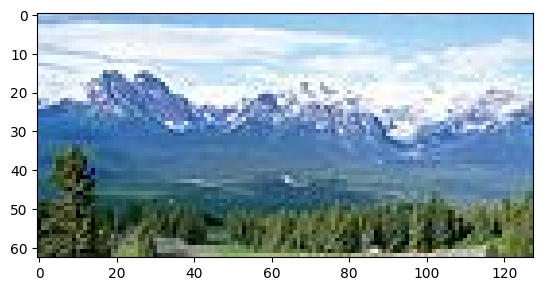

In [10]:
import matplotlib.pyplot as plt
import matplotlib.image as img

img_test = img.imread('images/1882.jpg')
plt.imshow(img_test)
plt.show()

# Yolo model을 이용한 객체인식 코드 실습

In [11]:
pip install git+https://github.com/keras-team/keras-preprocessing.git

  Cloning https://github.com/keras-team/keras-preprocessing.git to /tmp/pip-req-build-40lmupjj
  Running command git clone --filter=blob:none --quiet https://github.com/keras-team/keras-preprocessing.git /tmp/pip-req-build-40lmupjj
  Resolved https://github.com/keras-team/keras-preprocessing.git to commit 3e380065d4afc7347aaee8d89325a16b22158438
  Preparing metadata (setup.py) ... done


In [12]:
!pip install tensorflow==2.8.0

In [13]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

In [14]:
import cv2
import numpy as np

In [15]:
!pip install yolov3_tf2

In [16]:
import requests
import os
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from yolov3_tf2.models import YoloV3
from yolov3_tf2.utils import load_darknet_weights
from yolov3_tf2.utils import draw_outputs

# 파일 다운로드 함수
def download_file(url, dest):
    response = requests.get(url, stream=True)
    if response.status_code == 200:
        with open(dest, 'wb') as f:
            for chunk in response.iter_content(1024):
                f.write(chunk)
        print(f"Downloaded {url} to {dest}")
    else:
        print(f"Failed to download {url}")

# yolov3.weights 파일 다운로드
weights_url = 'https://github.com/patrick013/Object-Detection---Yolov3/blob/master/model/yolov3.weights?raw=true'
weights_path = 'yolov3.weights'

if not os.path.exists(weights_path):
    download_file(weights_url, weights_path)

In [17]:
# COCO 클래스 이름 파일 준비
coco_names_url = 'https://raw.githubusercontent.com/pjreddie/darknet/master/data/coco.names'
coco_names_path = 'coco.names'

if not os.path.exists(coco_names_path):
    download_file(coco_names_url, coco_names_path)

# YOLOv3 모델 로드
yolo = YoloV3(classes=80)
load_darknet_weights(yolo, weights_path)

# COCO 클래스 이름 로드
class_names = [c.strip() for c in open(coco_names_path).readlines()]


<ipython-input-17-a497314bfb4c>:10: DeprecationWarning: `product` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `prod` instead.
  load_darknet_weights(yolo, weights_path)


In [18]:
class_names

['person',
 'bicycle',
 'car',
 'motorbike',
 'aeroplane',
 'bus',
 'train',
 'truck',
 'boat',
 'traffic light',
 'fire hydrant',
 'stop sign',
 'parking meter',
 'bench',
 'bird',
 'cat',
 'dog',
 'horse',
 'sheep',
 'cow',
 'elephant',
 'bear',
 'zebra',
 'giraffe',
 'backpack',
 'umbrella',
 'handbag',
 'tie',
 'suitcase',
 'frisbee',
 'skis',
 'snowboard',
 'sports ball',
 'kite',
 'baseball bat',
 'baseball glove',
 'skateboard',
 'surfboard',
 'tennis racket',
 'bottle',
 'wine glass',
 'cup',
 'fork',
 'knife',
 'spoon',
 'bowl',
 'banana',
 'apple',
 'sandwich',
 'orange',
 'broccoli',
 'carrot',
 'hot dog',
 'pizza',
 'donut',
 'cake',
 'chair',
 'sofa',
 'pottedplant',
 'bed',
 'diningtable',
 'toilet',
 'tvmonitor',
 'laptop',
 'mouse',
 'remote',
 'keyboard',
 'cell phone',
 'microwave',
 'oven',
 'toaster',
 'sink',
 'refrigerator',
 'book',
 'clock',
 'vase',
 'scissors',
 'teddy bear',
 'hair drier',
 'toothbrush']

In [19]:
# 이미지 로드 및 전처리
def load_image(image_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (416, 416))
    img = img / 255.0
    return img[np.newaxis, ...].astype(np.float32), img

# 객체 탐지 수행
def predict_objects(model, image):
    boxes, scores, classes, nums = model(image)
    return boxes, scores, classes, nums

# 결과 시각화
def draw_boxes(image, boxes, scores, classes, nums, class_names):
    wh = np.flip(image.shape[0:2])
    for i in range(nums[0]):
        x1y1 = tuple((np.array(boxes[0][i][0:2]) * wh).astype(np.int32))
        x2y2 = tuple((np.array(boxes[0][i][2:4]) * wh).astype(np.int32))
        image = cv2.rectangle(image, x1y1, x2y2, (0, 255, 0), 2)
        image = cv2.putText(image, '{} {:.4f}'.format(class_names[int(classes[0][i])], scores[0][i]),
                            x1y1, cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
    return image

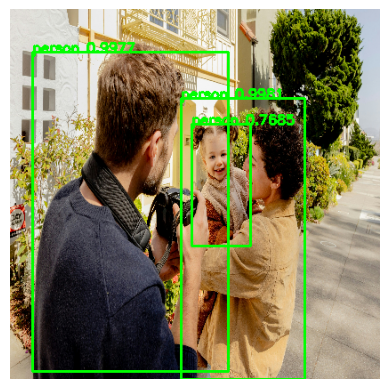

In [20]:
# 이미지 파일 경로
image_path = "example1.jpg"

# 객체 탐지 수행
image, orig_img = load_image(image_path)
boxes, scores, classes, nums = predict_objects(yolo, image)
result_img = draw_boxes(orig_img, boxes, scores, classes, nums, class_names)

# 결과 시각화
plt.imshow(result_img)
plt.axis('off')
plt.show()


#U-Net model을 이용한 semantic segmentation

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
from tensorflow.keras import layers, models

# 데이터셋 로드
dataset, info = tfds.load('oxford_iiit_pet', with_info=True)
train_dataset = dataset['train']
test_dataset = dataset['test']

# 데이터셋 크기 계산
num_train_examples = info.splits['train'].num_examples
num_test_examples = info.splits['test'].num_examples

# 이미지와 마스크 전처리 함수
def normalize(input_image, input_mask):
    input_image = tf.cast(input_image, tf.float32) / 255.0
    input_mask = tf.cast(input_mask, tf.float32) / 255.0
    return input_image, input_mask

def load_image_train(datapoint):
    input_image = tf.image.resize(datapoint['image'], (128, 128))
    input_mask = tf.image.resize(datapoint['segmentation_mask'], (128, 128))
    input_image, input_mask = normalize(input_image, input_mask)
    return input_image, input_mask

def load_image_test(datapoint):
    input_image = tf.image.resize(datapoint['image'], (128, 128))
    input_mask = tf.image.resize(datapoint['segmentation_mask'], (128, 128))
    input_image, input_mask = normalize(input_image, input_mask)
    return input_image, input_mask



Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

In [ ]:
# 학습 데이터셋 준비
BATCH_SIZE = 32
BUFFER_SIZE = 1000
train = train_dataset.map(load_image_train, num_parallel_calls=tf.data.experimental.AUTOTUNE)
train_dataset = train.cache().shuffle(BUFFER_SIZE).batch(BATCH_SIZE).repeat()
train_dataset = train_dataset.prefetch(buffer_size=tf.data.experimental.AUTOTUNE)

test = test_dataset.map(load_image_test)
test_dataset = test.batch(BATCH_SIZE)

# steps_per_epoch 및 validation_steps 계산
steps_per_epoch = np.ceil(num_train_examples / BATCH_SIZE).astype(int)
validation_steps = np.ceil(num_test_examples / BATCH_SIZE).astype(int)

print("Steps per epoch:", steps_per_epoch)
print("Validation steps:", validation_steps)

Steps per epoch: 115
Validation steps: 115


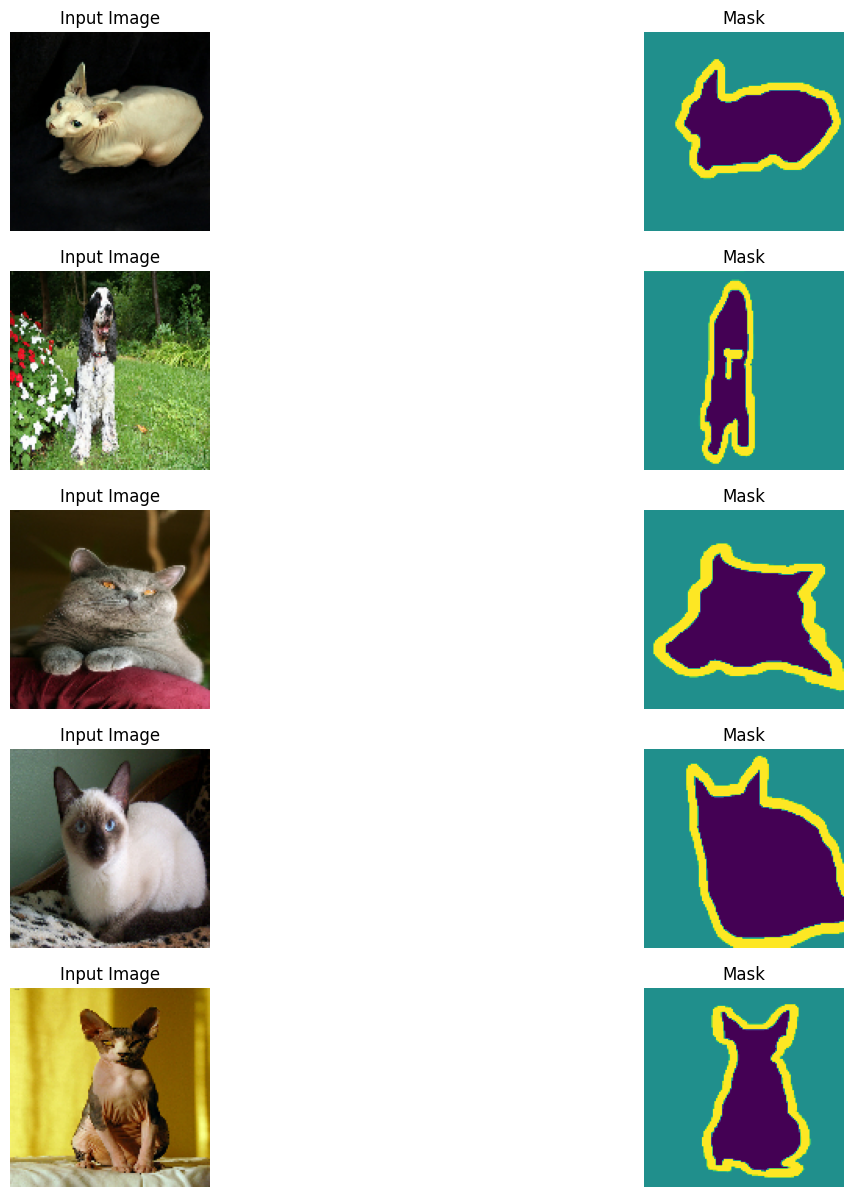

In [ ]:
import matplotlib.pyplot as plt

# 샘플 데이터 시각화
def display_sample_images(dataset, num_samples=5):
    plt.figure(figsize=(15, 15))
    for i, data in enumerate(dataset.take(num_samples)):
        input_image, input_mask = data
        plt.subplot(num_samples, 2, 2*i+1)
        plt.title('Input Image')
        plt.imshow(tf.keras.preprocessing.image.array_to_img(input_image))
        plt.axis('off')
        plt.subplot(num_samples, 2, 2*i+2)
        plt.title('Mask')
        plt.imshow(tf.keras.preprocessing.image.array_to_img(input_mask))
        plt.axis('off')
    plt.show()

# 학습 데이터셋에서 샘플 이미지와 마스크 시각화
display_sample_images(train)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

def small_unet_model(input_size=(128, 128, 3)):
    inputs = layers.Input(input_size)

    # 인코더 (Contracting Path)
    conv1 = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    conv1 = layers.Conv2D(32, 3, activation='relu', padding='same')(conv1)
    pool1 = layers.MaxPooling2D(pool_size=(2, 2))(conv1)

    conv2 = layers.Conv2D(64, 3, activation='relu', padding='same')(pool1)
    conv2 = layers.Conv2D(64, 3, activation='relu', padding='same')(conv2)
    pool2 = layers.MaxPooling2D(pool_size=(2, 2))(conv2)

    conv3 = layers.Conv2D(128, 3, activation='relu', padding='same')(pool2)
    conv3 = layers.Conv2D(128, 3, activation='relu', padding='same')(conv3)
    pool3 = layers.MaxPooling2D(pool_size=(2, 2))(conv3)

    # 중앙 (Bridge)
    conv4 = layers.Conv2D(256, 3, activation='relu', padding='same')(pool3)
    conv4 = layers.Conv2D(256, 3, activation='relu', padding='same')(conv4)

    # 디코더 (Expansive Path)
    up5 = layers.Conv2D(128, 2, activation='relu', padding='same')(layers.UpSampling2D(size=(2, 2))(conv4))
    merge5 = layers.concatenate([conv3, up5], axis=3)
    conv5 = layers.Conv2D(128, 3, activation='relu', padding='same')(merge5)
    conv5 = layers.Conv2D(128, 3, activation='relu', padding='same')(conv5)

    up6 = layers.Conv2D(64, 2, activation='relu', padding='same')(layers.UpSampling2D(size=(2, 2))(conv5))
    merge6 = layers.concatenate([conv2, up6], axis=3)
    conv6 = layers.Conv2D(64, 3, activation='relu', padding='same')(merge6)
    conv6 = layers.Conv2D(64, 3, activation='relu', padding='same')(conv6)

    up7 = layers.Conv2D(32, 2, activation='relu', padding='same')(layers.UpSampling2D(size=(2, 2))(conv6))
    merge7 = layers.concatenate([conv1, up7], axis=3)
    conv7 = layers.Conv2D(32, 3, activation='relu', padding='same')(merge7)
    conv7 = layers.Conv2D(32, 3, activation='relu', padding='same')(conv7)

    conv8 = layers.Conv2D(1, 1, activation='sigmoid')(conv7)

    model = models.Model(inputs=inputs, outputs=conv8)

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    return model

model = small_unet_model()
model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_10 (InputLayer)          [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_75 (Conv2D)             (None, 128, 128, 32  896         ['input_10[0][0]']               
                                )                                                                 
                                                                                                  
 conv2d_76 (Conv2D)             (None, 128, 128, 32  9248        ['conv2d_75[0][0]']              
                                )                                                             

In [ ]:
EPOCHS = 20

history = model.fit(train_dataset, epochs=EPOCHS, steps_per_epoch=steps_per_epoch, validation_data=test_dataset, validation_steps=validation_steps)


Epoch 1/20
115/115 [==============================] - 2220s 19s/step - loss: 0.0606 - accuracy: 0.0000e+00 - val_loss: 0.0425 - val_accuracy: 0.0000e+00
Epoch 2/20
104/115 [==========================>...] - ETA: 2:44 - loss: 0.0423 - accuracy: 0.0000e+00

In [ ]:
import matplotlib.pyplot as plt

def display(display_list):
    plt.figure(figsize=(15, 15))

    title = ['Input Image', 'True Mask', 'Predicted Mask']

    for i in range(len(display_list)):
        plt.subplot(1, len(display_list), i+1)
        plt.title(title[i])
        plt.imshow(tf.keras.preprocessing.image.array_to_img(display_list[i]))
        plt.axis('off')
    plt.show()

for image, mask in test_dataset.take(1):
    sample_image, sample_mask = image, mask
    pred_mask = model.predict(sample_image)
    display([sample_image[0], sample_mask[0], pred_mask[0]])
